In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.tree import plot_tree
from sklearn.utils import resample
import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import StratifiedKFold, cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\tsymb\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
project_root = Path().resolve().parent
df = pd.read_csv(project_root / "data/cleaned.csv")
df

,issuer.tradingSymbol,reportingOwner.name,transactionDate,amounts.shares,amounts.pricePerShare,ownershipNature.directOrIndirectOwnership,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,...,746,747,748,749,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans
0,HBNC,NEFF JAMES D,2009-01-30,4000.0,12.4975,D,False,True,False,1,...,3.611793,3.626802,3.618046,3.629302,14.810847,2.800167,1.682722,-0.495984,-0.639443,0
1,WLFC,JACOBS SY,2009-01-28,1910.0,8.6000,I,False,False,True,0,...,13.015418,13.015418,12.986280,13.025130,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0
2,WLFC,JACOBS SY,2009-01-29,613.0,8.6600,I,False,False,True,0,...,13.015418,12.986280,13.025130,13.034844,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1
3,WLFC,JACOBS SY,2009-01-30,808.0,8.5400,I,False,False,True,0,...,12.986280,13.025130,13.034844,13.073694,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0
4,HXL,HENNEMUTH ROBERT,2009-01-30,400.0,8.0400,D,False,True,False,1,...,18.959692,18.895298,18.922897,19.033287,9.024040,2.269244,1.074058,-0.547370,-0.639443,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,SPE,GOLDSTEIN PHILLIP,2023-12-28,44.0,11.7500,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,4.873516,2.724795,-0.828549,0.159188,-0.713086,1
97150,SPE,GOLDSTEIN PHILLIP,2023-12-28,1319.0,11.7800,D,True,True,False,1,...,9.395709,9.395709,9.395709,9.395709,11.808925,2.727904,1.346064,0.159188,-0.713086,0
97151,SFBC,STILWELL JOSEPH,2023-12-28,7.0,38.7500,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,2.210827,4.251506,-1.188667,2.150396,-0.713086,1
97152,SFBC,STILWELL JOSEPH,2023-12-29,404.0,39.0000,I,False,False,True,0,...,37.531849,37.531849,37.531849,37.531849,9.045543,4.260137,-0.732465,2.150396,-0.639443,1


# Baseline Model

In [3]:
df["target"] = (
    df['5'] >
    df['0']
    ).astype('int8')
df["target"].sum()

np.int64(55795)

In [4]:
num_cols = df.select_dtypes(include=["number", "bool"]).columns
num_cols = [c for c in num_cols if not (str(c).isdigit() and 0 <= int(c) <= 750)]
df_numeric = df[num_cols]
df_numeric = df_numeric.drop(columns=["transaction_month", "amounts.shares", "amounts.pricePerShare","filing_count_reportingOwner.name", "trades_14d", "holding_change_percent"])
df_numeric

,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,month_sin,month_cos,high_frequency_trader,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans,target
0,False,True,False,1,5.000000e-01,0.866025,0,0,1,14.810847,2.800167,1.682722,-0.495984,-0.639443,0,0
1,False,False,True,0,5.000000e-01,0.866025,0,0,0,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0,1
2,False,False,True,0,5.000000e-01,0.866025,0,0,0,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1,1
3,False,False,True,0,5.000000e-01,0.866025,0,0,0,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0,0
4,False,True,False,1,5.000000e-01,0.866025,0,0,1,9.024040,2.269244,1.074058,-0.547370,-0.639443,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,True,True,False,1,-2.449294e-16,1.000000,1,0,0,4.873516,2.724795,-0.828549,0.159188,-0.713086,1,1
97150,True,True,False,1,-2.449294e-16,1.000000,1,0,1,11.808925,2.727904,1.346064,0.159188,-0.713086,0,1
97151,False,False,True,0,-2.449294e-16,1.000000,1,1,0,2.210827,4.251506,-1.188667,2.150396,-0.713086,1,0
97152,False,False,True,0,-2.449294e-16,1.000000,1,1,0,9.045543,4.260137,-0.732465,2.150396,-0.639443,1,0


                Modell  Accuracy   ROC AUC  Precision    Recall
0        Random Forest  0.601260  0.642444   0.594410  0.961424
1  Logistic Regression  0.573812  0.543284   0.576431  0.971366
2              XGBoost  0.661240  0.734916   0.723354  0.663733


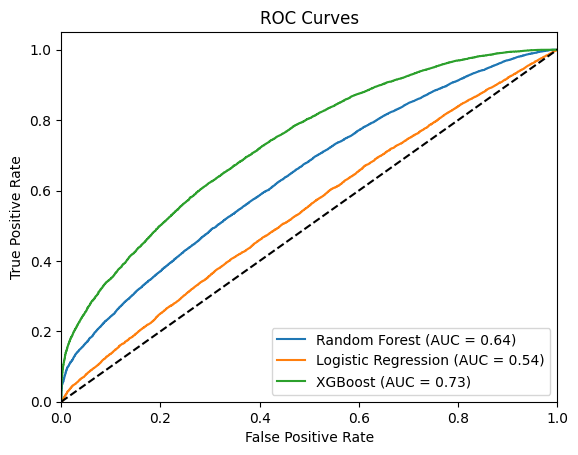

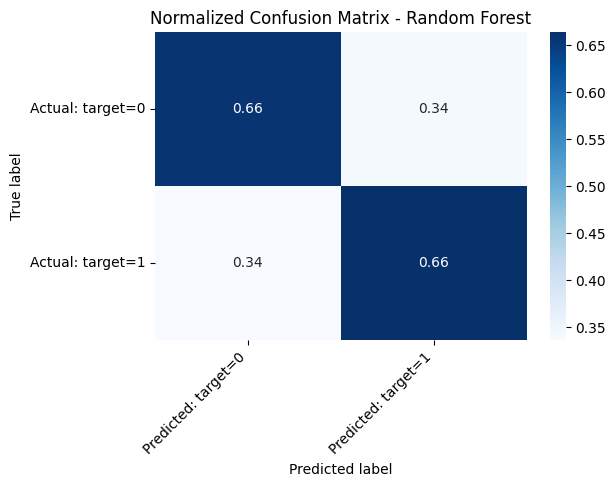

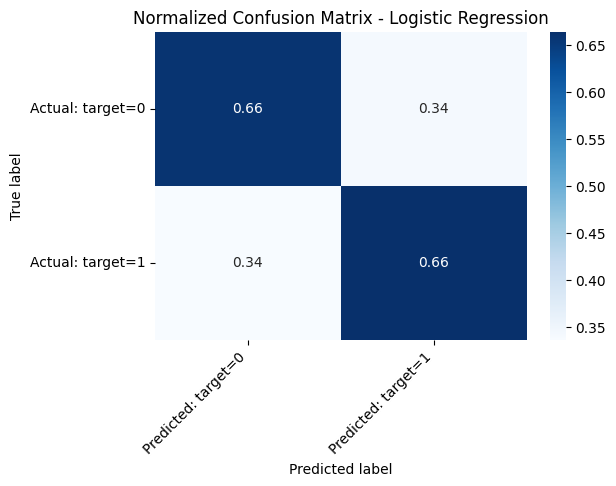

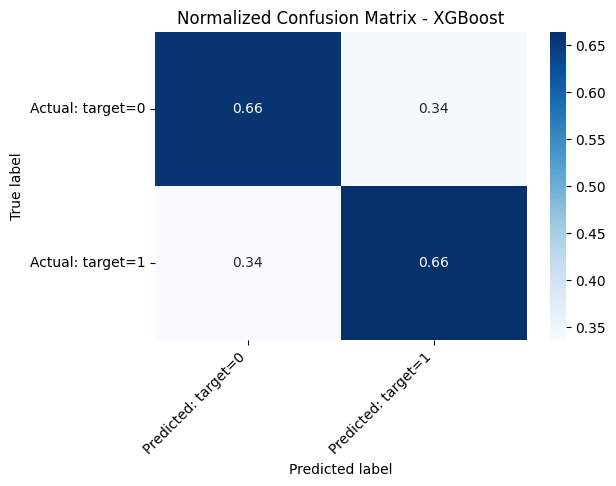

Feature importance for each model:
                                               Logistic Regression  \
high_frequency_trader                                     0.123854   
scaled_trades_14d                                         0.112294   
high_price                                                0.110415   
reportingOwner.relationship.isOfficer                     0.095037   
direct_ownership                                          0.075583   
boxcox_amounts.pricePerShare                              0.074104   
reportingOwner.relationship.isDirector                    0.059713   
month_cos                                                 0.041131   
month_sin                                                 0.032116   
boxcox_amounts_shares                                     0.026861   
kmeans                                                    0.023103   
scaled_filing_count_reportingOwner.name                   0.021865   
high_change_in_holdings                                

In [5]:
y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=420)
y_train_enc = np.asarray(y_train).astype(int)
neg, pos = np.bincount(y_train_enc)
scale_pos = neg / pos
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1200,
        max_depth=10,
        max_features="sqrt",
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight=None,
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=420
    ),
    "Logistic Regression": LogisticRegression(max_iter=10000),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=420,
        n_jobs=-1,
    ),
}

results = []
for model_name, model in models.items():
    if model_name == "XGBoost":
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    accuracy  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results.append({
        "Modell": model_name,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.savefig(project_root / "exports/roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()

for model_name, model in models.items():
    cm = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cm, index=['Actual: target=0', 'Actual: target=1'],
                         columns=['Predicted: target=0', 'Predicted: target=1'])
    cm_values = df_cm.values.astype('float')
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)

    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name}')
    png = f"exports/normalized_confusion_matrix_{model_name}.png"
    plt.savefig(project_root / png, dpi=300, bbox_inches='tight')
    plt.show()

feature_importances = pd.DataFrame(index=X_train.columns)
if "Logistic Regression" in models:
    feature_importances["Logistic Regression"] = np.abs(models["Logistic Regression"].coef_[0])
if "Random Forest" in models:
    feature_importances["Random Forest"] = models["Random Forest"].feature_importances_
if "XGBoost" in models:
    feature_importances["XGBoost"] = models["XGBoost"].feature_importances_

feature_importances = feature_importances.sort_values(by="Logistic Regression", ascending=False)
print("Feature importance for each model:")
print(feature_importances)

In [ ]:
log_reg = models["Logistic Regression"].fit(X_train, y_train)
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns)
or_ = np.exp(coefs)

or_table = pd.DataFrame({
    "Coefficient": coefs,
    "Odds Ratio": or_,
})

or_table["percent chance target/not target"] = np.where(
    or_table["Odds Ratio"]>=1,
    (or_table["Odds Ratio"]-1)*100,
    -(1-or_table["Odds Ratio"])*100
).round(1)

or_table = or_table.reindex(or_table["Coefficient"].abs().sort_values(ascending=False).index)
or_table

,Koeffizient,Odds Ratio,percent chance target/not target
high_frequency_trader,-0.123854,0.883508,-11.6
scaled_trades_14d,0.112294,1.118841,11.9
high_price,-0.110415,0.895463,-10.5
reportingOwner.relationship.isOfficer,0.095037,1.099700,10.0
direct_ownership,-0.075583,0.927203,-7.3
boxcox_amounts.pricePerShare,0.074104,1.076919,7.7
reportingOwner.relationship.isDirector,0.059713,1.061532,6.2
month_cos,-0.041131,0.959704,-4.0
month_sin,-0.032116,0.968394,-3.2
boxcox_amounts_shares,0.026861,1.027225,2.7


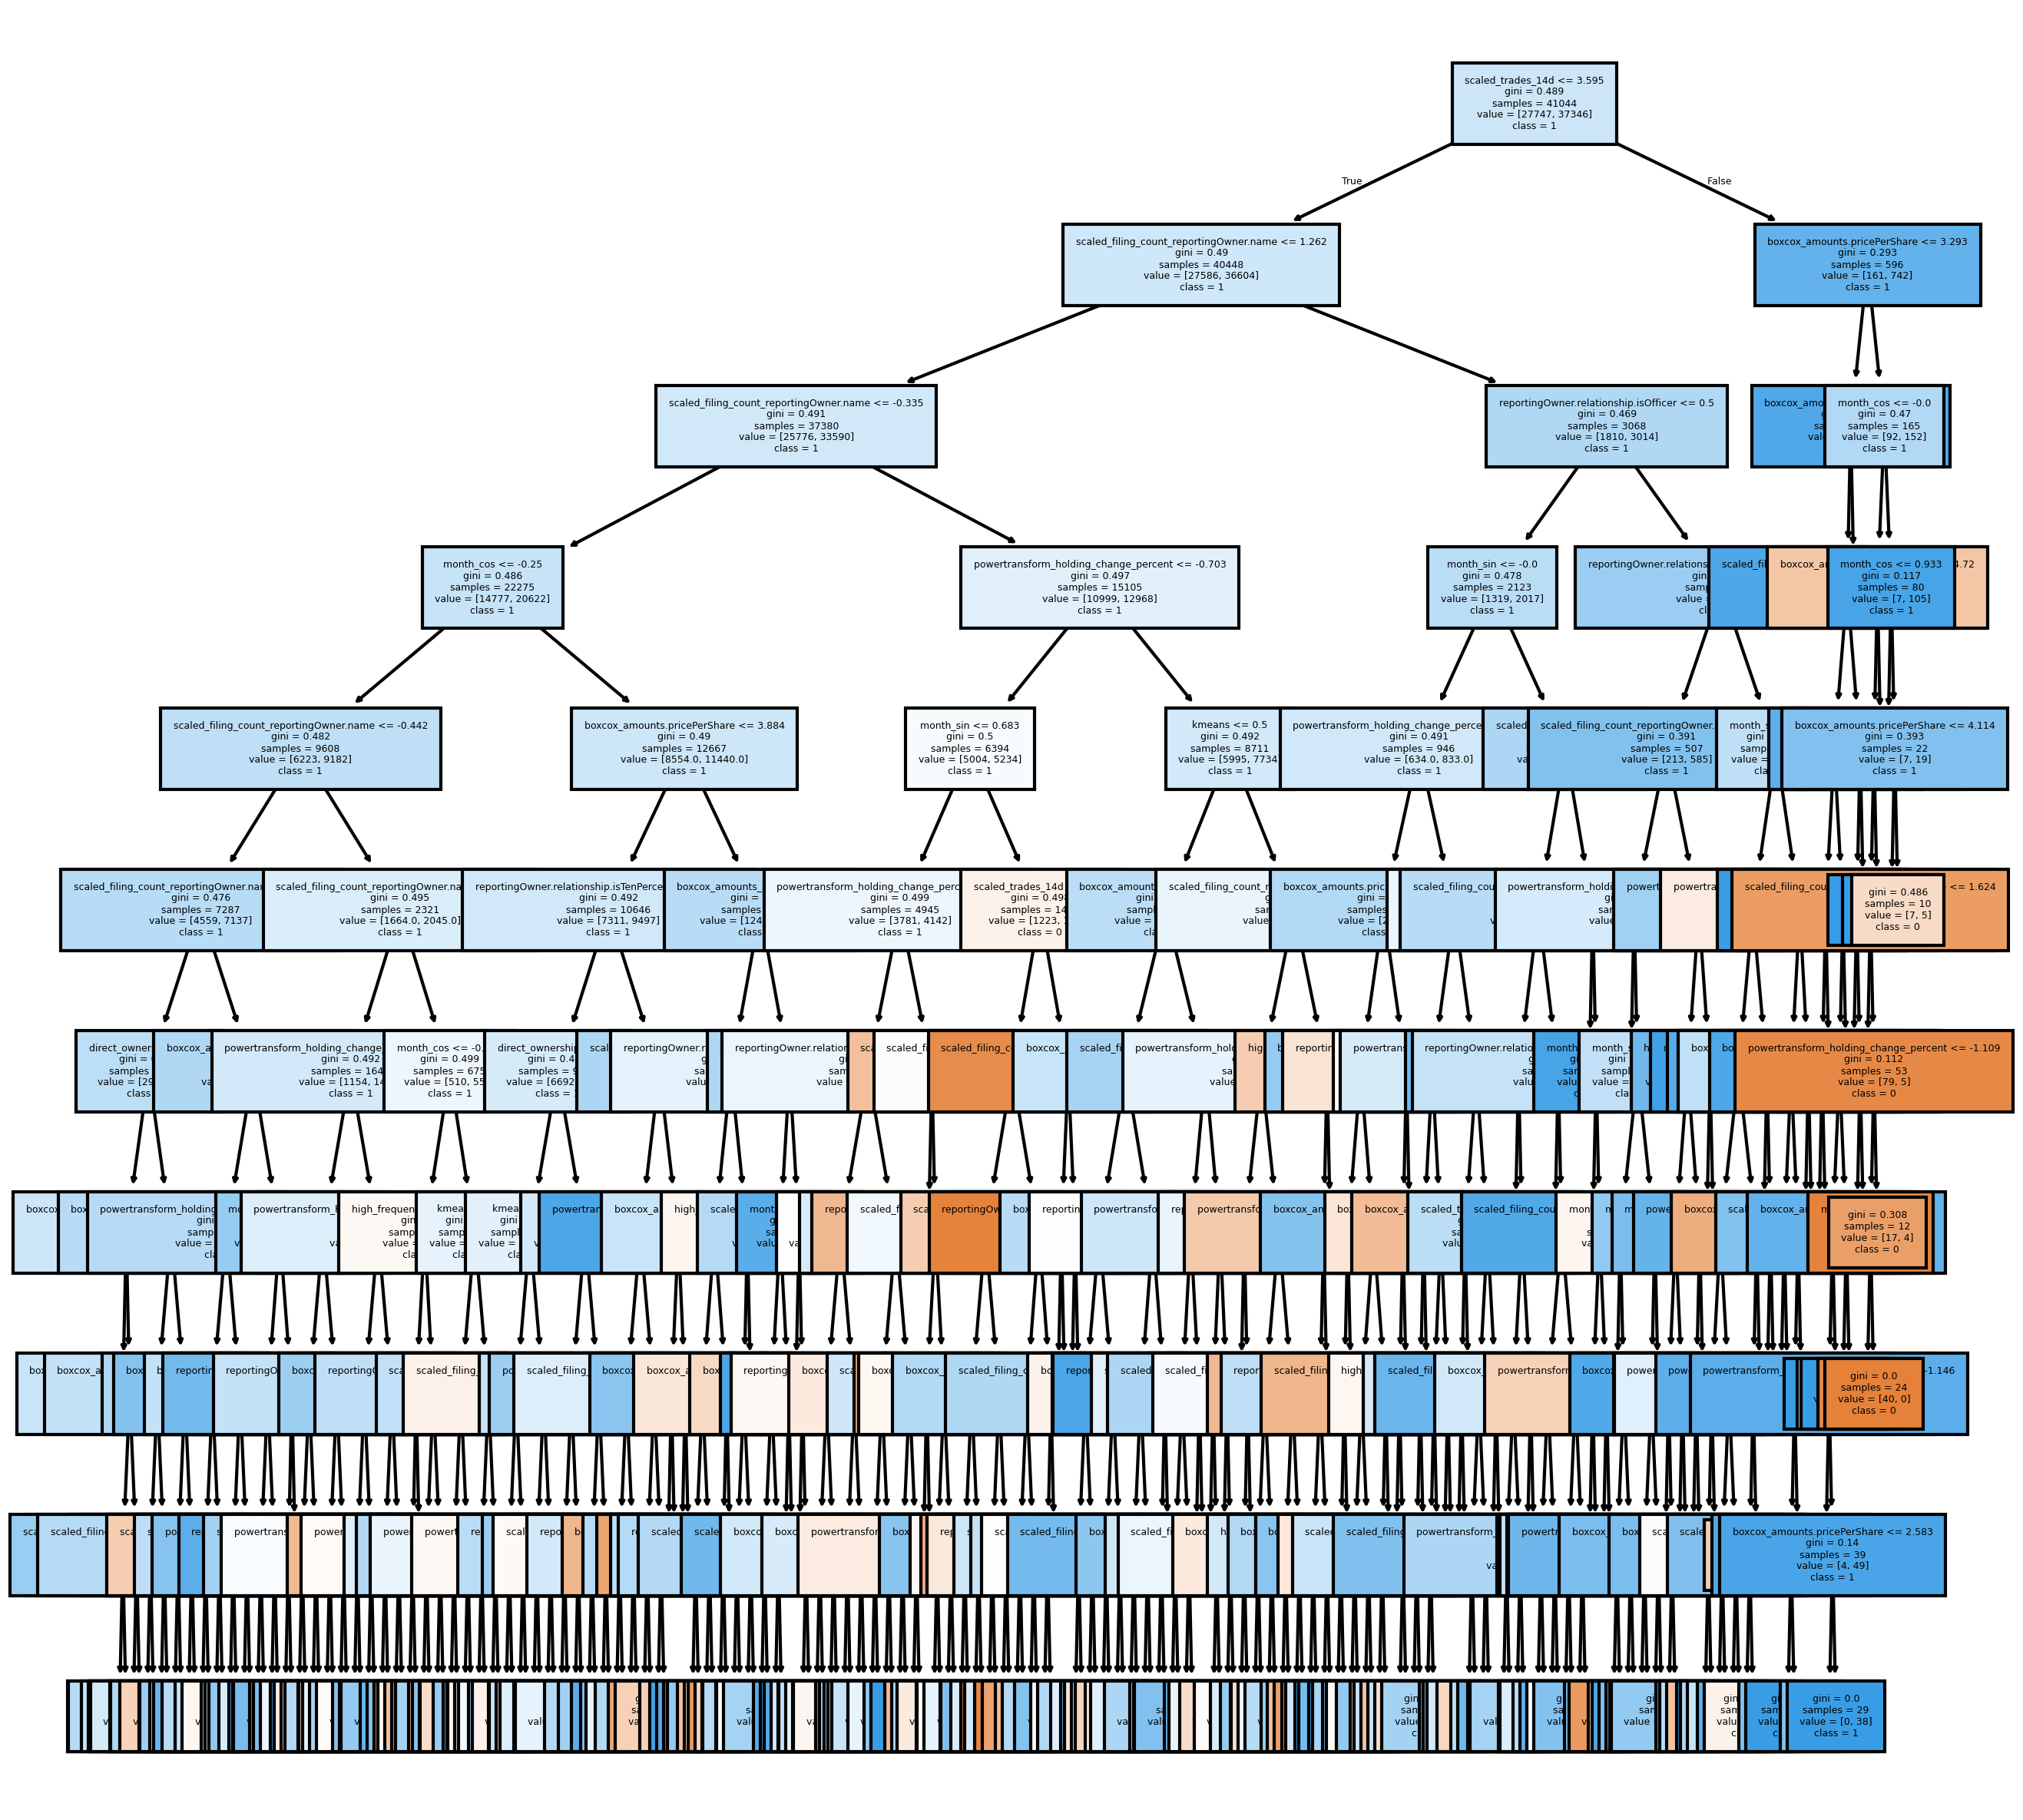

In [ ]:
fig, ax = plt.subplots(figsize=(10,10),dpi=300,)
fn = list(X_train.columns)
cn = [str(cls) for cls in np.unique(y_train)]

estimator = models["Random Forest"].estimators_[0]

plot_tree(estimator,
feature_names=fn,
class_names=cn,
filled=True,
fontsize=3,
ax=ax)

fig.savefig(project_root / "exports/tree_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# Fine Tune

In [8]:
# find optimal threshold since confusion matrix is not good with default 0.5
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75]
results_threshold = []

y_pred_prob = models["Random Forest"].predict_proba(X_test)[:, 1]

for thresh in thresholds:
    y_pred_custom = (y_pred_prob >= thresh).astype(int)
    results_threshold.append({
        "Threshold": thresh,
        "Accuracy": accuracy_score(y_test, y_pred_custom),
        "Precision": precision_score(y_test, y_pred_custom, zero_division=0),
        "Recall": recall_score(y_test, y_pred_custom, zero_division=0),
        "F1-Score": 2 * (precision_score(y_test, y_pred_custom, zero_division=0) * recall_score(y_test, y_pred_custom, zero_division=0)) / (precision_score(y_test, y_pred_custom, zero_division=0) + recall_score(y_test, y_pred_custom, zero_division=0) + 1e-10),
        "Predicted 1 %": (y_pred_custom == 1).sum() / len(y_pred_custom) * 100
    })

threshold_df = pd.DataFrame(results_threshold)
print(threshold_df)

   Threshold  Accuracy  Precision    Recall  F1-Score  Predicted 1 %
0       0.50  0.601260   0.594410  0.961424  0.734629      92.851128
1       0.55  0.611148   0.636782  0.750992  0.689188      67.702193
2       0.60  0.549328   0.721104  0.350503  0.471719      27.903060
3       0.65  0.472786   0.920022  0.089378  0.162928       5.576869
4       0.70  0.453573   0.972281  0.049552  0.094298       2.925673
5       0.75  0.444871   0.985600  0.033469  0.064740       1.949409


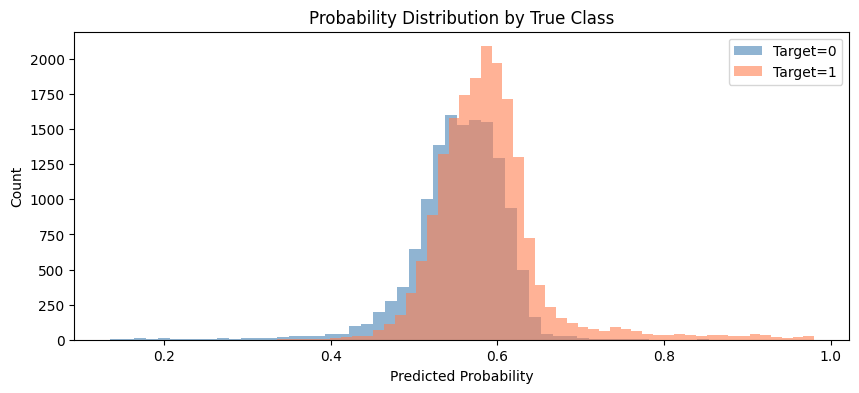

Top 5 Features:
scaled_trades_14d                          0.208086
boxcox_amounts.pricePerShare               0.176231
scaled_filing_count_reportingOwner.name    0.135657
boxcox_amounts_shares                      0.130104
powertransform_holding_change_percent      0.115848
Name: Random Forest, dtype: float64

scaled_trades_14d:
          count      mean       std       min     25%       50%       75%  \
target                                                                      
0       41359.0 -0.046548  0.913069 -0.713086 -0.5658 -0.344871  0.096986   
1       55795.0  0.034504  1.058543 -0.713086 -0.5658 -0.344871  0.170629   

             max  
target            
0       6.062064  
1       6.135706  

boxcox_amounts.pricePerShare:
          count      mean       std       min       25%       50%       75%  \
target                                                                        
0       41359.0  2.827883  1.078913  0.712822  1.981428  2.940770  3.613801   
1       55795.0

In [9]:
plt.figure(figsize=(10, 4))
plt.hist(y_pred_prob[y_test==0], bins=50, alpha=0.6, label='Target=0', color='steelblue')
plt.hist(y_pred_prob[y_test==1], bins=50, alpha=0.6, label='Target=1', color='coral')
plt.xlabel('Predicted Probability')
plt.ylabel('Count')
plt.title('Probability Distribution by True Class')
plt.legend()
plt.show()

top_features = feature_importances["Random Forest"].nlargest(5)
print("Top 5 Features:")
print(top_features)

for feat in top_features.index:
    print(f"\n{feat}:")
    print(df_numeric.groupby('target')[feat].describe())

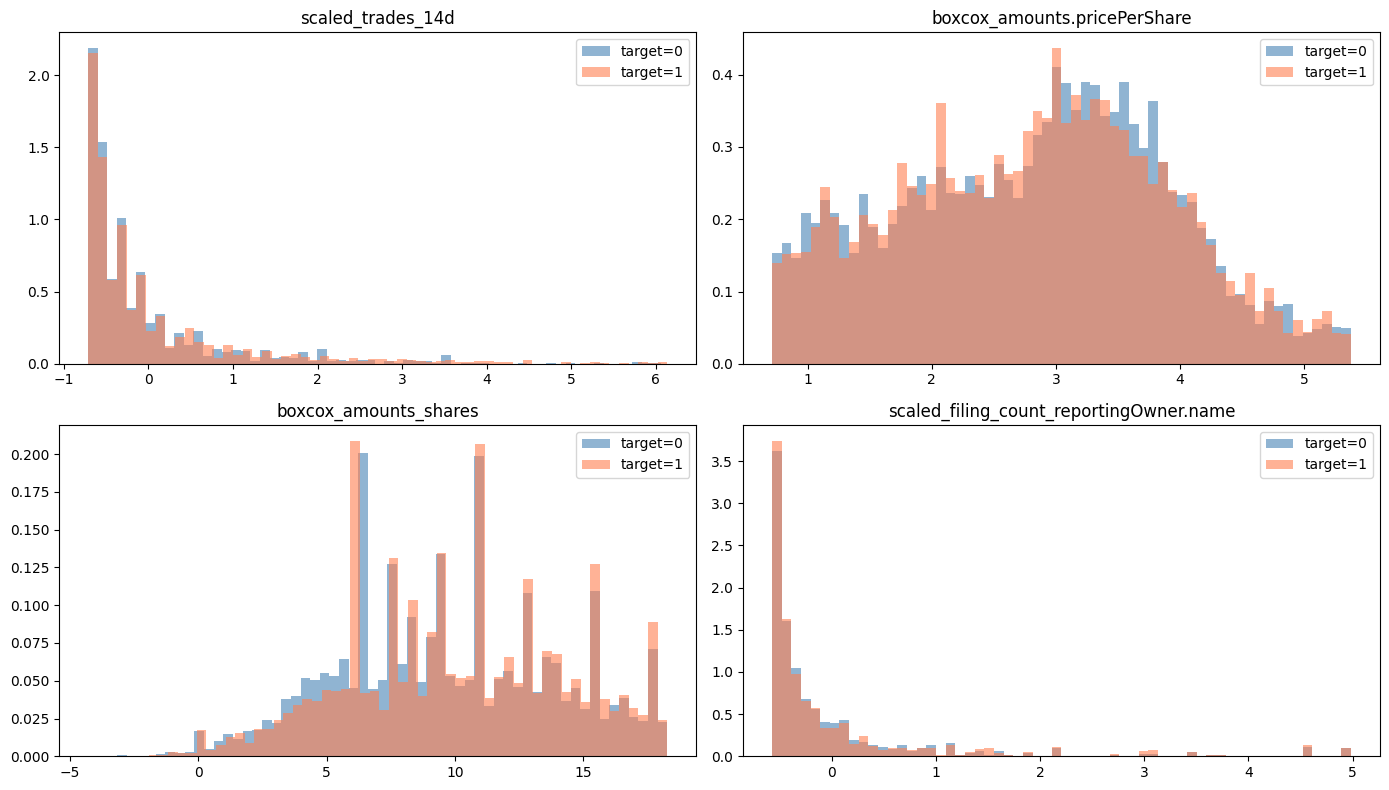

In [9]:
features_to_check = [
    'scaled_trades_14d', 
    'boxcox_amounts.pricePerShare',
    'boxcox_amounts_shares',
    'scaled_filing_count_reportingOwner.name'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), features_to_check):
    vals_0 = df_numeric[df_numeric['target'] == 0][feat].dropna()
    vals_1 = df_numeric[df_numeric['target'] == 1][feat].dropna()
    ax.hist(vals_0, bins=60, alpha=0.6, label='target=0', density=True, color='steelblue')
    ax.hist(vals_1, bins=60, alpha=0.6, label='target=1', density=True, color='coral')
    ax.set_title(feat)
    ax.legend()
plt.tight_layout()
plt.savefig(project_root / 'exports/histogram_of_features.png', dpi=500)
plt.show()

In [12]:
# featur engineering: trade volume ratio, large trade flag, high activity flag, interaction term
df_numeric['trade_volume_ratio'] = (
    df_numeric['boxcox_amounts_shares'] / 
    (df_numeric['scaled_trades_14d'] + 1e-6)
)

df_numeric['is_large_trade'] = (
    df_numeric['boxcox_amounts_shares'] > 
    df_numeric['boxcox_amounts_shares'].quantile(0.9)
).astype(int)

df_numeric['is_high_activity'] = (
    df_numeric['scaled_trades_14d'] > 
    df_numeric['scaled_trades_14d'].quantile(0.85)
).astype(int)

df_numeric['activity_x_size'] = (
    df_numeric['scaled_trades_14d'] * 
    df_numeric['boxcox_amounts_shares']
)

In [ ]:
# test multiple targets on rf
df_numeric_copy = df_numeric.copy()
for col in ['2', '3', '4', '5', '6', '7', '8', '9', '10', '20', '60']:
    if col in df.columns:
        df_numeric_copy[f"target_{col}d"] = (df[col] > df['0']).astype('int8')
        auc = roc_auc_score(
            df_numeric_copy[f"target_{col}d"],
            models["Random Forest"].predict_proba(X)[:, 1]
        )
        print(f"{col} Days with AUC: {auc:.3f}")

df_numeric_copy["target_percent"] = ((df['5'] / df['0'] - 1) > 0.02).astype('int8')
auc = roc_auc_score(
                    df_numeric_copy["target_percent"],
                    models["Random Forest"].predict_proba(X)[:, 1]
)
print(f"AUC: {auc:.3f}")

2 Days with AUC: 0.599
3 Days with AUC: 0.639
4 Days with AUC: 0.665
5 Days with AUC: 0.698
6 Days with AUC: 0.668
7 Days with AUC: 0.645
8 Days with AUC: 0.639
9 Days with AUC: 0.633
10 Days with AUC: 0.631
20 Days with AUC: 0.615
60 Days with AUC: 0.564


In [14]:
df_numeric

,reportingOwner.relationship.isDirector,reportingOwner.relationship.isOfficer,reportingOwner.relationship.isTenPercentOwner,direct_ownership,month_sin,month_cos,high_frequency_trader,high_price,high_change_in_holdings,boxcox_amounts_shares,boxcox_amounts.pricePerShare,powertransform_holding_change_percent,scaled_filing_count_reportingOwner.name,scaled_trades_14d,kmeans,target,trade_volume_ratio,is_large_trade,is_high_activity,activity_x_size
0,False,True,False,1,5.000000e-01,0.866025,0,0,1,14.810847,2.800167,1.682722,-0.495984,-0.639443,0,0,-23.162146,0,0,-9.470692
1,False,False,True,0,5.000000e-01,0.866025,0,0,0,12.763522,2.349076,-0.534718,-0.487419,-0.639443,0,1,-19.960408,0,0,-8.161544
2,False,False,True,0,5.000000e-01,0.866025,0,0,0,9.971760,2.357344,-0.949839,-0.487419,-0.565800,1,1,-17.624209,0,0,-5.642022
3,False,False,True,0,5.000000e-01,0.866025,0,0,0,10.613207,2.340755,-0.879243,-0.487419,-0.492157,0,0,-21.564718,0,0,-5.223365
4,False,True,False,1,5.000000e-01,0.866025,0,0,1,9.024040,2.269244,1.074058,-0.547370,-0.639443,1,1,-14.112369,0,0,-5.770359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97149,True,True,False,1,-2.449294e-16,1.000000,1,0,0,4.873516,2.724795,-0.828549,0.159188,-0.713086,1,1,-6.834413,0,0,-3.475235
97150,True,True,False,1,-2.449294e-16,1.000000,1,0,1,11.808925,2.727904,1.346064,0.159188,-0.713086,0,1,-16.560336,0,0,-8.420777
97151,False,False,True,0,-2.449294e-16,1.000000,1,1,0,2.210827,4.251506,-1.188667,2.150396,-0.713086,1,0,-3.100370,0,0,-1.576509
97152,False,False,True,0,-2.449294e-16,1.000000,1,1,0,9.045543,4.260137,-0.732465,2.150396,-0.639443,1,0,-14.145997,0,0,-5.784109


Training after balancing:
target
0    27703
1    27703
Name: count, dtype: int64
                Modell  Threshold  Accuracy   ROC AUC  Precision    Recall
0        Random Forest       0.55  0.504725  0.637815   0.793448  0.185547
1  Logistic Regression       0.55  0.460372  0.543278   0.644958  0.133442
2              XGBoost       0.55  0.662394  0.727785   0.714625  0.685738


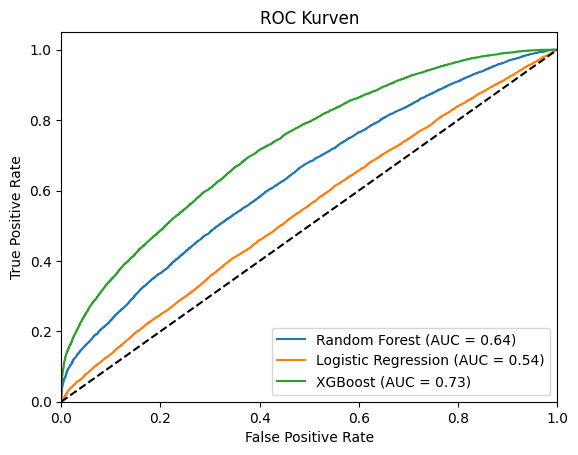

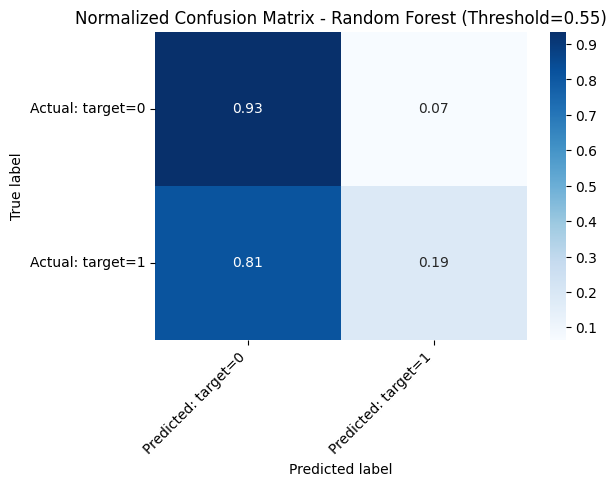

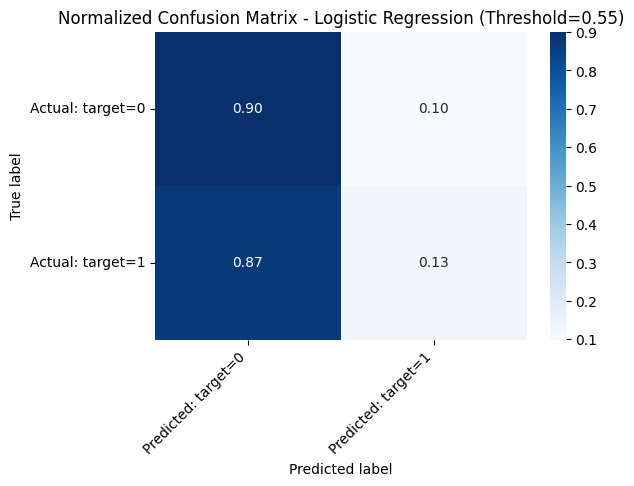

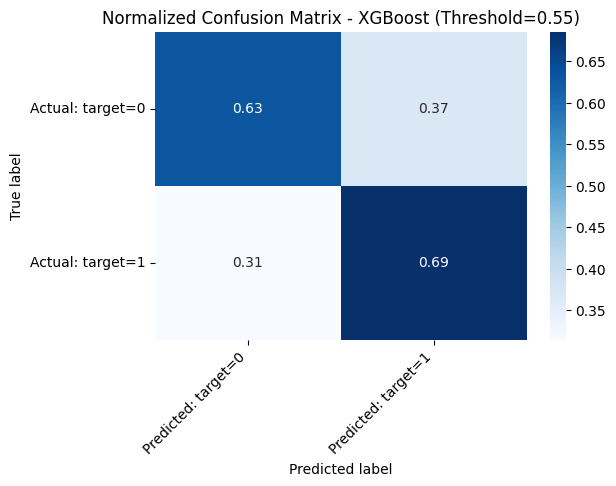

Feature importance for each model:
                                               Logistic Regression  \
scaled_trades_14d                                         0.131837   
high_frequency_trader                                     0.119979   
is_high_activity                                          0.107692   
high_price                                                0.103906   
reportingOwner.relationship.isOfficer                     0.093392   
boxcox_amounts.pricePerShare                              0.069431   
is_large_trade                                            0.063599   
direct_ownership                                          0.058258   
reportingOwner.relationship.isDirector                    0.057452   
month_cos                                                 0.044466   
boxcox_amounts_shares                                     0.031959   
month_sin                                                 0.031772   
high_change_in_holdings                                

In [15]:
THRESHOLD = 0.55

y = df_numeric['target']
x_columns = [col for col in df_numeric.columns if col != "target"]
X = df_numeric[x_columns]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=420
)

df_train = X_train.copy()
df_train['target'] = y_train
df_majority = df_train[df_train['target'] == df_train['target'].value_counts().idxmax()]
df_minority = df_train[df_train['target'] == df_train['target'].value_counts().idxmin()]
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=420
)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(
    frac=1, random_state=420
)
X_train_bal = df_balanced.drop(columns=['target'])
y_train_bal = df_balanced['target']

print("Training after balancing:")
print(y_train_bal.value_counts())

scale_pos = len(df_majority) / len(df_minority)

models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=1200,
        max_depth=10,
        max_features="sqrt",
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight="balanced",
        bootstrap=True,
        oob_score=True,
        n_jobs=-1,
        random_state=420
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=10000,
        class_weight="balanced",
    ),
    "XGBoost": XGBClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos, 
        eval_metric="auc",
        early_stopping_rounds=50,
        random_state=420,
        n_jobs=-1,
    ),
}

results = []
for model_name, model in models.items():
    if model_name == "XGBoost":
        model.fit(
            X_train_bal, y_train_bal,
            eval_set=[(X_test, y_test)],
            verbose=False
        )
    else:
        model.fit(X_train_bal, y_train_bal)

    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= THRESHOLD).astype(int)

    accuracy  = accuracy_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_pred_prob)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    results.append({
        "Modell": model_name,
        "Threshold": THRESHOLD,
        "Accuracy": accuracy,
        "ROC AUC": roc_auc,
        "Precision": precision,
        "Recall": recall
    })
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

results_df = pd.DataFrame(results)
print(results_df)

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Kurven')
plt.legend(loc="lower right")
plt.show()

for model_name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_pred_prob >= THRESHOLD).astype(int)

    cm = confusion_matrix(y_test, y_pred)
    df_cm = pd.DataFrame(cm, index=['Actual: target=0', 'Actual: target=1'],
                         columns=['Predicted: target=0', 'Predicted: target=1'])
    cm_values = df_cm.values.astype('float')
    cm_normalized = cm_values / cm_values.sum(axis=1)[:, np.newaxis]
    df_cm_normalized = pd.DataFrame(cm_normalized, index=df_cm.index, columns=df_cm.columns)

    plt.figure(figsize=(6, 4))
    heatmap = sns.heatmap(df_cm_normalized, annot=True, fmt='.2f', cmap="Blues")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right')
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title(f'Normalized Confusion Matrix - {model_name} (Threshold={THRESHOLD})')
    plt.show()

feature_importances = pd.DataFrame(index=X_train_bal.columns)

if "Logistic Regression" in models:
    feature_importances["Logistic Regression"] = np.abs(
        models["Logistic Regression"].coef_[0]
    )
if "Random Forest" in models:
    feature_importances["Random Forest"] = models["Random Forest"].feature_importances_

if "XGBoost" in models:
    feature_importances["XGBoost"] = models["XGBoost"].feature_importances_

feature_importances = feature_importances.sort_values(
    by="Logistic Regression", ascending=False
)
print("Feature importance for each model:")
print(feature_importances)

In [16]:
# train each model with top features and compare results
TOP_N = 10

retrain_results = []
retrained_models = {}

for model_name in models.keys():
    top_features = feature_importances[model_name].nlargest(TOP_N).index.tolist()
    
    X_train_top = X_train_bal[top_features]
    X_test_top  = X_test[top_features]

    if model_name == "Random Forest":
        model_retrained = RandomForestClassifier(
            n_estimators=1200, max_depth=10, max_features="sqrt",
            min_samples_split=20, min_samples_leaf=10,
            class_weight="balanced", bootstrap=True,
            oob_score=True, n_jobs=-1, random_state=420
        )
        model_retrained.fit(X_train_top, y_train_bal)

    elif model_name == "Logistic Regression":
        model_retrained = LogisticRegression(
            max_iter=10000, class_weight="balanced"
        )
        model_retrained.fit(X_train_top, y_train_bal)

    elif model_name == "XGBoost":
        model_retrained = XGBClassifier(
            n_estimators=1000, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos, eval_metric="auc",
            early_stopping_rounds=50, random_state=420, n_jobs=-1
        )
        model_retrained.fit(
            X_train_top, y_train_bal,
            eval_set=[(X_test_top, y_test)],
            verbose=False
        )

    retrained_models[model_name] = {
        "model": model_retrained,
        "features": top_features
    }

    y_pred_prob = model_retrained.predict_proba(X_test_top)[:, 1]
    y_pred      = (y_pred_prob >= THRESHOLD).astype(int)

    retrain_results.append({
        "Modell":     model_name,
        "Top N":      TOP_N,
        "Features":   top_features,
        "Accuracy":   accuracy_score(y_test, y_pred),
        "ROC AUC":    roc_auc_score(y_test, y_pred_prob),
        "Precision":  precision_score(y_test, y_pred, zero_division=0),
        "Recall":     recall_score(y_test, y_pred),
    })


retrain_df = pd.DataFrame(retrain_results).drop(columns="Features")
print(retrain_df.to_string(index=False))

print("Top Features:")
for model_name, data in retrained_models.items():
    print(f"\n{model_name}:")
    for f in data["features"]:
        print(f"  - {f}")

             Modell  Top N  Accuracy  ROC AUC  Precision   Recall
      Random Forest     10  0.502792 0.631096   0.765517 0.192991
Logistic Regression     10  0.453791 0.530561   0.679678 0.091769
            XGBoost     10  0.670909 0.743301   0.721115 0.695844
Top Features:

Random Forest:
  - boxcox_amounts.pricePerShare
  - scaled_trades_14d
  - activity_x_size
  - scaled_filing_count_reportingOwner.name
  - boxcox_amounts_shares
  - trade_volume_ratio
  - powertransform_holding_change_percent
  - month_sin
  - month_cos
  - kmeans

Logistic Regression:
  - scaled_trades_14d
  - high_frequency_trader
  - is_high_activity
  - high_price
  - reportingOwner.relationship.isOfficer
  - boxcox_amounts.pricePerShare
  - is_large_trade
  - direct_ownership
  - reportingOwner.relationship.isDirector
  - month_cos

XGBoost:
  - kmeans
  - is_high_activity
  - scaled_trades_14d
  - boxcox_amounts.pricePerShare
  - scaled_filing_count_reportingOwner.name
  - direct_ownership
  - reportingOwne

In [ ]:
# hyperparameter tuning for random forest with optuna
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=420)
N_TRIALS = 50

def objective_rf(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 400, 1500, step=100),
        "max_depth":         trial.suggest_int("max_depth", 4, 20),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5]),
        "min_samples_split": trial.suggest_int("min_samples_split", 5, 40),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 3, 20),
        "class_weight":      "balanced",
        "bootstrap":         True,
        "n_jobs":            -1,
        "random_state":      420,
    }
    clf = RandomForestClassifier(**params)
    scores = cross_val_score(clf, X_train_bal, y_train_bal, cv=CV,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_rf = optuna.create_study(direction="maximize", sampler=TPESampler(seed=420))
study_rf.optimize(objective_rf, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Random Forest best AUC: {study_rf.best_value:.4f}")
print(f"Best params: {study_rf.best_params}")

# Random Forest best AUC: 0.7220
# Best params: {'n_estimators': 1200, 'max_depth': 19, 'max_features': 'sqrt', 'min_samples_split': 10, 'min_samples_leaf': 4}

Best trial: 35. Best value: 0.721997: 100%|██████████| 50/50 [2:35:42<00:00, 186.84s/it]  

Random Forest best AUC: 0.7220
Best params: {'n_estimators': 1200, 'max_depth': 19, 'max_features': 'sqrt', 'min_samples_split': 10, 'min_samples_leaf': 4}


In [ ]:
# hyperparameter tuning for logistic regression with optuna
def objective_lr(trial):
    # Solver-Penalty als feste Kombinationen kodieren
    solver_penalty = trial.suggest_categorical("solver_penalty", [
        "lbfgs_l2",
        "lbfgs_none",
        "saga_l1",
        "saga_l2",
        "saga_none",
    ])
    solver, penalty_str = solver_penalty.split("_")
    penalty = None if penalty_str == "none" else penalty_str

    params = {
        "C":            trial.suggest_float("C", 1e-4, 10.0, log=True),
        "penalty":      penalty,
        "solver":       solver,
        "max_iter":     10000,
        "class_weight": "balanced",
        "random_state": 420,
    }
    clf = LogisticRegression(**params)
    scores = cross_val_score(clf, X_train_bal, y_train_bal, cv=CV,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_lr = optuna.create_study(direction="maximize", sampler=TPESampler(seed=420))
study_lr.optimize(objective_lr, n_trials=N_TRIALS, show_progress_bar=True)
print(f"Logistic Regression best AUC: {study_lr.best_value:.4f}")
print(f"Best params: {study_lr.best_params}")

# Logistic Regression best AUC: 0.5480
# Best params: {'solver_penalty': 'lbfgs_l2', 'C': 0.0011159192530565195}

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 49. Best value: 0.547957: 100%|██████████| 50/50 [30:02<00:00, 36.06s/it] 

Logistic Regression best AUC: 0.5480
Best params: {'solver_penalty': 'lbfgs_l2', 'C': 0.0011159192530565195}


In [ ]:
# hyperparameter tuning for xgboost with optuna
def objective_xgb(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 300, 1200, step=100),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 20),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "scale_pos_weight":  scale_pos,
        "eval_metric":       "auc",
        "random_state":      420,
        "n_jobs":            -1,
    }
    clf = XGBClassifier(**params)
    scores = cross_val_score(clf, X_train_bal, y_train_bal, cv=CV,
                             scoring="roc_auc", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize", sampler=TPESampler(seed=420))
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, show_progress_bar=True)
print(f"XGBoost best AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

# XGBoost best AUC: 0.7538
# Best params: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.1971509374202014, 'subsample': 0.8628273353390353, 'colsample_bytree': 0.7142240991986449, 'min_child_weight': 1, 'gamma': 0.04863119746077804, 'reg_alpha': 1.2095966829619182, 'reg_lambda': 0.007035941405184785}

Best trial: 13. Best value: 0.753831: 100%|██████████| 50/50 [13:42<00:00, 16.45s/it]

XGBoost best AUC: 0.7538
Best params: {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.1971509374202014, 'subsample': 0.8628273353390353, 'colsample_bytree': 0.7142240991986449, 'min_child_weight': 1, 'gamma': 0.04863119746077804, 'reg_alpha': 1.2095966829619182, 'reg_lambda': 0.007035941405184785}
